**CENTRALIZED**

Implementation of the centralized model that runs on the server side.

For Helath Related Issues, we usually should use high interpretability models, but in a FL setup, those models do not make much sense, as we work with iterations and GD, that highly suits NN models. This project is not about it, but rather the FL technicality.

I've used **Diabetes 130-US Hospitals for Years 1999-2008** dataset for this project as it can be undertood that hospitals can not share the data between themselves, only sharing finalized models, so it makes sense in a realistic way.

This dataset covers ten years (1999–2008) of clinical care at 130 US hospitals. Each row is a hospital record of a diabetic patient who underwent lab tests, received medications, and stayed up to 14 days. The goal is to predict whether a patient will be readmitted to the hospital within 30 days of discharge.

This dataset is hard, a little bit of datapreparation must be done, and the *state of the art* models that use straight models are not that good, arround 0.667  (AUC-ROC) for XGBoost.

As mentioned early i've used a NN and obtained 



In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from IPython.display import display, Markdown
import zipfile

with zipfile.ZipFile('diabetes_data/diabetes.zip', 'r') as z:
    print(z.namelist())  # see what's inside
    z.extractall('diabetes_data/')

df = pd.read_csv('diabetes_data/diabetic_data.csv')
print(df.shape)
display(df.head(5))

print(df.count())



['diabetic_data.csv', 'IDS_mapping.csv']
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


encounter_id                101766
patient_nbr                 101766
race                        101766
gender                      101766
age                         101766
weight                      101766
admission_type_id           101766
discharge_disposition_id    101766
admission_source_id         101766
time_in_hospital            101766
payer_code                  101766
medical_specialty           101766
num_lab_procedures          101766
num_procedures              101766
num_medications             101766
number_outpatient           101766
number_emergency            101766
number_inpatient            101766
diag_1                      101766
diag_2                      101766
diag_3                      101766
number_diagnoses            101766
max_glu_serum                 5346
A1Cresult                    17018
metformin                   101766
repaglinide                 101766
nateglinide                 101766
chlorpropamide              101766
glimepiride         

**Data preprocessing**

In [35]:
df.replace('?', np.nan, inplace=True)

# Check missing values
print(df.isnull().sum().sort_values(ascending=False).head(10))

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
patient_nbr              0
dtype: int64


In [36]:
import pandas as pd
import numpy as np

COLS_TO_DROP = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code', 
                'encounter_id', 'patient_nbr']

DECEASED_IDS = [11, 19, 20, 21]

ADMISSION_TYPE_MAP = {
    1: 'emergency', 2: 'urgent',   3: 'elective',
    4: 'newborn',   5: 'unknown',  6: 'unknown',
    7: 'emergency', 8: 'unknown'
}

ADMISSION_SOURCE_MAP = {
    1: 'referral',  2: 'referral',  3: 'referral',
    4: 'transfer',  5: 'transfer',  6: 'transfer',
    10: 'transfer', 22: 'transfer', 25: 'transfer', 26: 'transfer',
    7: 'emergency', 8: 'other',     9: 'unknown',
    11: 'newborn',  12: 'newborn',  13: 'newborn',
    14: 'newborn',  23: 'newborn',  24: 'newborn',
    15: 'unknown',  17: 'unknown',  20: 'unknown',  21: 'unknown'
}

AGE_MAP = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}

MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

MED_MAP = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2}



In [37]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw CSV and replace ? with NaN."""
    df = pd.read_csv(path)
    df.replace('?', np.nan, inplace=True)
    return df


def drop_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop high-missing and ID columns."""
    return df.drop(columns=COLS_TO_DROP)


def remove_deceased(df: pd.DataFrame) -> pd.DataFrame:
    """Remove patients who died — they cannot be readmitted."""
    return df[~df['discharge_disposition_id'].isin(DECEASED_IDS)].copy()


def create_target(df: pd.DataFrame) -> pd.DataFrame:
    """Create binary target: 1 if readmitted within 30 days, 0 otherwise."""
    df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
    df.drop(columns=['readmitted'], inplace=True)
    return df


def group_discharge(x):
    if x in [11, 19, 20, 21]: return 'expired'
    elif x in [1, 6, 8]:      return 'home'
    elif x in [2, 3, 4, 5]:   return 'transfer'
    elif x in [13, 14]:       return 'hospice'
    elif x == 7:               return 'ama'
    else:                      return 'other'


def group_icd9(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'): return 'other'
        c = float(code)
        if   390 <= c <= 459 or c == 785: return 'circulatory'
        elif 460 <= c <= 519 or c == 786: return 'respiratory'
        elif 520 <= c <= 579 or c == 787: return 'digestive'
        elif 250 <= c <= 250.99:          return 'diabetes'
        elif 800 <= c <= 999:             return 'injury'
        elif 710 <= c <= 739:             return 'musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'genitourinary'
        elif 140 <= c <= 239:             return 'neoplasms'
        else:                             return 'other'
    except:
        return 'other'


def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all feature encoding and grouping."""
    # Ordinal
    df['age'] = df['age'].map(AGE_MAP)

    # Clinical groupings
    df['admission_type_id']       = df['admission_type_id'].map(ADMISSION_TYPE_MAP)
    df['admission_source_id']     = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
    df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)

    # ICD-9 diagnosis codes
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(group_icd9)

    # Medication columns
    for col in MED_COLS:
        if col in df.columns:
            df[col] = df[col].map(MED_MAP)

    df['change']      = (df['change'] == 'Ch').astype(int)
    df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

    # One-hot encode categoricals
    df = pd.get_dummies(df, columns=[
        'diag_1', 'diag_2', 'diag_3',
        'admission_type_id', 'admission_source_id',
        'discharge_disposition_id', 'race', 'gender'
    ])

    return df


def prepare_data(path: str, verbose: bool = True) -> tuple:
    """
    Full pipeline from raw CSV to X, y arrays.
    Returns X, y as numpy arrays.
    """
    df = load_data(path)
    df = drop_columns(df)
    df = remove_deceased(df)
    df = create_target(df)      # must be before encode_features
    df.dropna(inplace=True)
    df = encode_features(df)

    if verbose:
        print(f"Dataset shape: {df.shape}")
        print(f"Class distribution:\n{df['readmitted_binary'].value_counts()}")

    X = df.drop(columns=['readmitted_binary']).values
    y = df['readmitted_binary'].values

    return X, y


# ── Usage ─────────────────────────────────────────────────────────────────────

X, y = prepare_data('diabetes_data/diabetic_data.csv')

Dataset shape: (96437, 86)
Class distribution:
readmitted_binary
0    85371
1    11066
Name: count, dtype: int64


In [38]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# First split off test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then split train into train + validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Same data prep
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)
print(np.bincount(y_train_resampled))  # should be ~58k / 58k

# Rebuild DataLoader with resampled data
X_train_t = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_resampled, dtype=torch.long)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=1024, shuffle=True)

Train: (65576, 85), Val: (11573, 85), Test: (19288, 85)
[58046 58046]


Class Distribution:
1    58046
0    58046
Name: count, dtype: int64

Class Proportions:
1    0.5
0    0.5
Name: proportion, dtype: float64


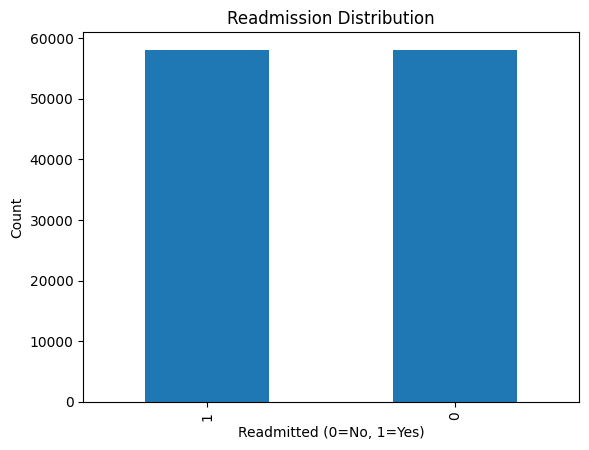

In [39]:
# Check class distribution
print("Class Distribution:")
print(pd.Series(y_train_t).value_counts())
print("\nClass Proportions:")
print(pd.Series(y_train_t).value_counts(normalize=True))

# Visualize
import matplotlib.pyplot as plt
pd.Series(y_train_t).value_counts().plot(kind='bar', title='Readmission Distribution')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

In [ ]:
# Simple MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

In [41]:
input_dim = X_train_scaled.shape[1]  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(input_dim=input_dim, hidden_dim=256, output_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss()

In [42]:
# Training loop

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t.to(device))
        val_loss = criterion(val_logits, y_val_t.to(device))  # ✅ compute loss
        val_preds = val_logits.argmax(dim=1).cpu()
        val_acc = (val_preds == y_val_t).float().mean()

    scheduler.step(val_loss)  # ✅ step on loss, not accuracy

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

Epoch 0 | Val Loss: 0.6108 | Val Acc: 0.649
Epoch 10 | Val Loss: 0.5404 | Val Acc: 0.724
Epoch 20 | Val Loss: 0.5350 | Val Acc: 0.731
Epoch 30 | Val Loss: 0.5281 | Val Acc: 0.736
Epoch 40 | Val Loss: 0.5315 | Val Acc: 0.734
Epoch 50 | Val Loss: 0.5293 | Val Acc: 0.736
Epoch 60 | Val Loss: 0.5328 | Val Acc: 0.734
Epoch 70 | Val Loss: 0.5284 | Val Acc: 0.736
Epoch 80 | Val Loss: 0.5341 | Val Acc: 0.733
Epoch 90 | Val Loss: 0.5287 | Val Acc: 0.737


In [43]:
print(np.bincount(y_train))  # what does your training set look like?

[58046  7530]


In [44]:
# Eval
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()

from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84     17076
           1       0.17      0.34      0.23      2212

    accuracy                           0.73     19288
   macro avg       0.54      0.56      0.53     19288
weighted avg       0.82      0.73      0.77     19288



In [45]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score

# Force numeric conversion
X_test_tensor = torch.tensor(X_test_scaled.astype(np.float32))

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor.cuda())
    y_proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f}")

AUC-ROC: 0.605


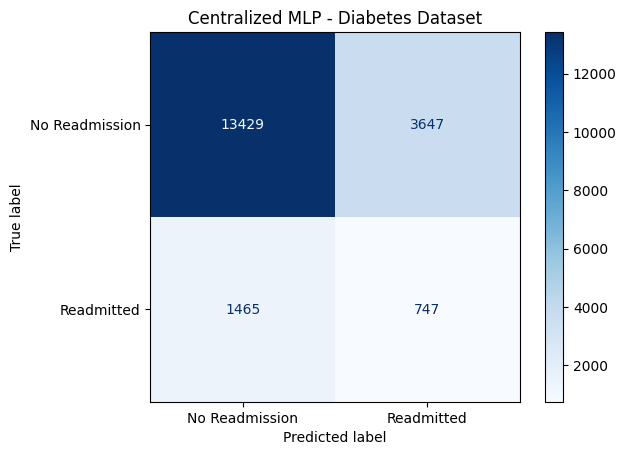

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmission', 'Readmitted'])
disp.plot(cmap='Blues')
plt.title('Centralized MLP - Diabetes Dataset')
plt.show()

Best threshold: 0.260
Best F1: 0.239


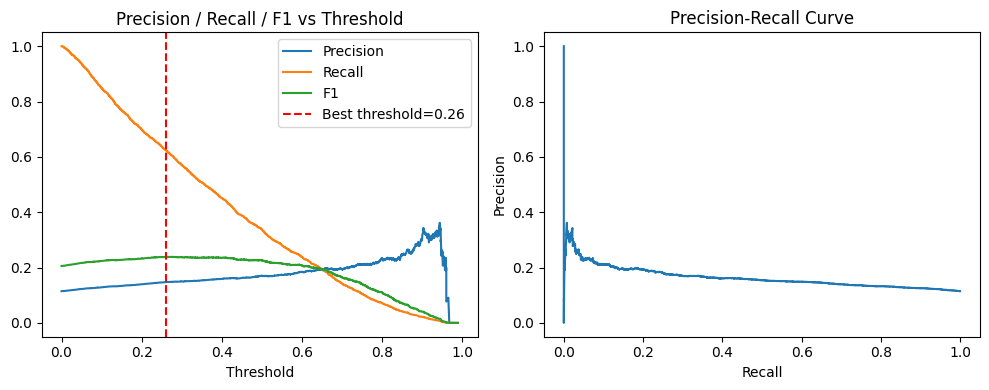

              precision    recall  f1-score   support

           0       0.92      0.53      0.67     17076
           1       0.15      0.63      0.24      2212

    accuracy                           0.54     19288
   macro avg       0.53      0.58      0.46     19288
weighted avg       0.83      0.54      0.62     19288



In [47]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities (make sure to use scaled data)
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

# Compute precision/recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1: {f1_scores[best_idx]:.3f}")

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision / Recall / F1 vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

# Apply best threshold
preds_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, preds_tuned))